In [2]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q6: How many sales transactions were recorded in each month, and are there any seasonal variations in transaction volume?

In [7]:
#code for Query 6
from pprint import pprint

pipeline = [
    {
        "$group": {
            "_id": {"$month": "$saleDate"},
            "total_transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

monthly_sales = list(collection.aggregate(pipeline))
pprint(monthly_sales)

monthly_sales_df = pd.DataFrame(monthly_sales)

month_names = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
               7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}

monthly_sales_df.rename(columns={"_id": "Month", "total_transactions": "Total Transactions"}, inplace=True)

monthly_sales_df["Month"]= monthly_sales_df["Month"].map(month_names)

monthly_sales_df



[{'_id': 1, 'total_transactions': 444},
 {'_id': 2, 'total_transactions': 359},
 {'_id': 3, 'total_transactions': 419},
 {'_id': 4, 'total_transactions': 394},
 {'_id': 5, 'total_transactions': 426},
 {'_id': 6, 'total_transactions': 418},
 {'_id': 7, 'total_transactions': 437},
 {'_id': 8, 'total_transactions': 414},
 {'_id': 9, 'total_transactions': 389},
 {'_id': 10, 'total_transactions': 444},
 {'_id': 11, 'total_transactions': 423},
 {'_id': 12, 'total_transactions': 433}]


,Month,Total Transactions
0,January,444
1,February,359
2,March,419
3,April,394
4,May,426
5,June,418
6,July,437
7,August,414
8,September,389
9,October,444


## Code for Visualization

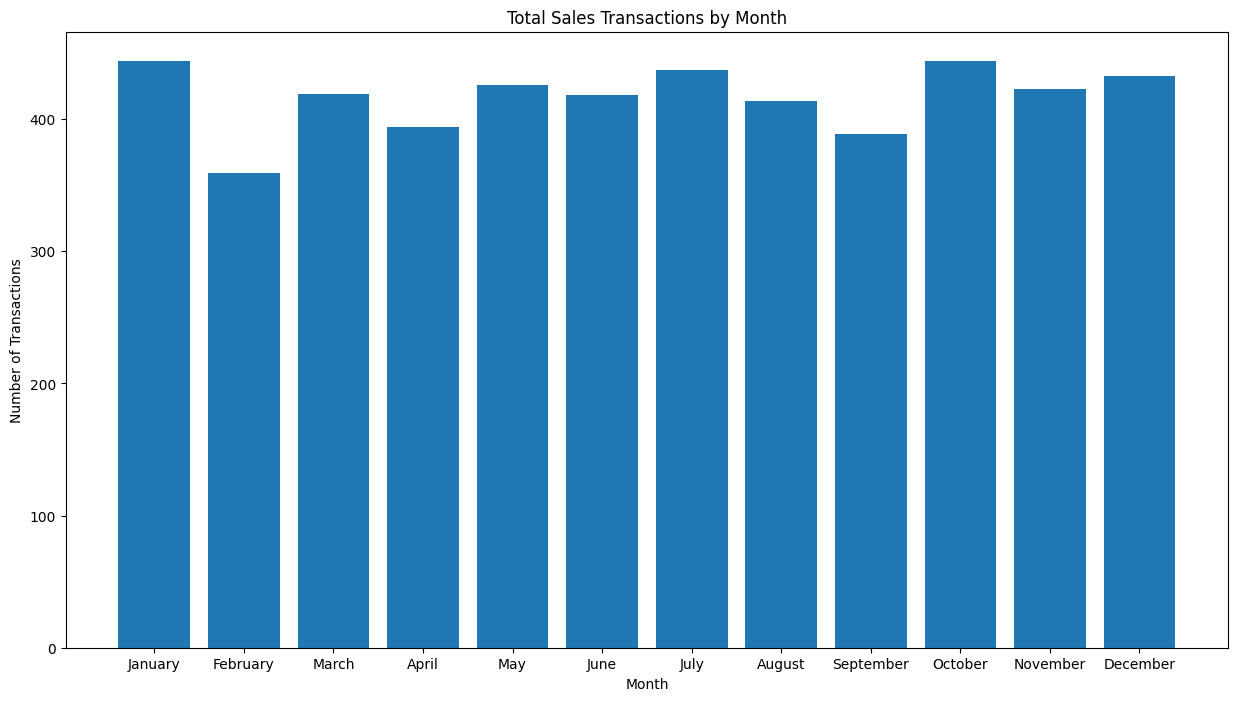

In [12]:
plt.figure(figsize=(15, 8))

plt.bar(monthly_sales_df["Month"], monthly_sales_df["Total Transactions"])

plt.title("Total Sales Transactions by Month")
plt.ylabel("Number of Transactions")
plt.xlabel("Month")

plt.show()
